Grid Point 61 / 61 (K=200, SNR=50dB)  |  MC Trial: 100 / 100    rid Point 9 / 61 (K=200, SNR=-2dB)  |  MC Trial: 39 / 100    
Simulation complete.


┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\matt\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\matt\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\matt\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\matt\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\matt\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\matt\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\matt\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194


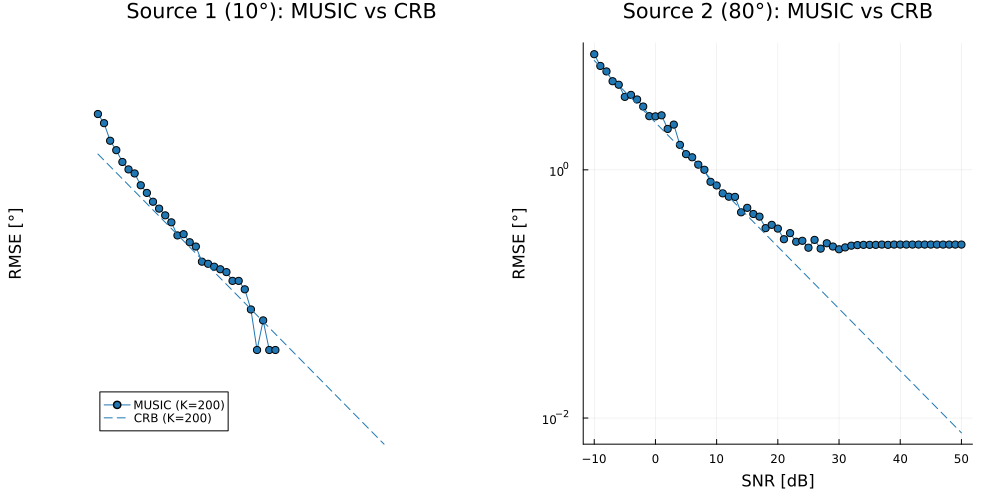

In [1]:
using ArraySignalProcessing
using LinearAlgebra
using Statistics
using Plots
import Measures

# --- Base Parameters ---
fc = 150e6
pa = IsotropicArray([0 0 0 0; -1.5 -0.5 0.5 1.5])
c_0 = 3e8

true_angles_deg = [10.0, 80.0]
true_angles_rad = deg2rad.(true_angles_deg)
d = length(true_angles_rad)

# Reduced Simulation Grids
snrs_db = collect(-10:50) # Sweep from -5dB to +30dB in 1dB steps
snapshots = [200] # Fixed to 100 snapshots
mc_trials = 100 # Reduced from 100

# --- Helper Functions ---
function get_deterministic_signals(d, max_K)
    s = zeros(ComplexF64, d, max_K)
    for i in 1:d
        f_offset = 0.01 * i 
        s[i, :] .= exp.(1im * 2π * f_offset .* (0:(max_K-1)))
    end
    return s
end

am_wrapper(θ) = pa(reshape(θ, 1, :), fc, c_0)

function evaluate_music_vs_crb()
    rmse_matrix = zeros(Float64, length(snrs_db), length(snapshots), d)
    crb_matrix = zeros(Float64, length(snrs_db), length(snapshots), d)

    max_K = maximum(snapshots)
    s_full = get_deterministic_signals(d, max_K)
    A_true = am_wrapper(true_angles_rad)
    N_sens = size(A_true, 1)

    # Narrowed search grid (0° to 90°, 181 points)
    search_grid = deg2rad.(LinRange(0, 90, 361))

    # --- Setup Counters ---
    total_grid_points = length(snapshots) * length(snrs_db)
    grid_counter = 0

    for (j, K) in enumerate(snapshots)
        s_k = s_full[:, 1:K]
        
        # Precompute the clean signal matrix
        S_clean = A_true * s_k

        for (i, snr) in enumerate(snrs_db)
            grid_counter += 1
            nvar = 10^(-snr/10)
            noise_scale = sqrt(nvar / 2)
            
            # 1. Calculate Conditional CRB
            crb_cov = conditional_crb(s_k, snr, am_wrapper, true_angles_rad)
            crb_std_deg = rad2deg.(sqrt.(abs.(diag(crb_cov)[1:d])))
            crb_matrix[i, j, :] .= crb_std_deg
            
            # 2. Run Monte Carlo for MUSIC
            squared_errors = zeros(Float64, d)
            valid_trials = 0
            
            for trial in 1:mc_trials
                # --- Progress Tracker ---
                mc_trials%10 == 0 && print("\rGrid Point $grid_counter / $total_grid_points (K=$K, SNR=$(snr)dB)  |  MC Trial: $trial / $mc_trials    ")
                mc_trials%10 == 0 && flush(stdout)
                
                # Generate noise and add to precomputed clean signal
                noise = noise_scale .* (randn(ComplexF64, N_sens, K) .+ 1im .* randn(ComplexF64, N_sens, K))
                X = S_clean .+ noise
                
                Rxx = (X * X') ./ K

                # Evaluate using the library function
                P = music(pa, Rxx, d, search_grid, fc)
                est_doas_rad = find_doas(search_grid, P, d)
                
                # Only accumulate error if exactly 'd' peaks were found
                if length(est_doas_rad) == d
                    est_doas_deg = sort(rad2deg.(est_doas_rad))
                    squared_errors .+= (est_doas_deg .- true_angles_deg).^2
                    valid_trials += 1
                end
            end
            
            # Compute RMSE using only the valid trials. Assign NaN if all trials failed.
            if valid_trials > 0
                rmse_matrix[i, j, :] .= sqrt.(squared_errors ./ valid_trials)
            else
                rmse_matrix[i, j, :] .= NaN
            end
        end # Ends the `for (i, snr)` loop
    end # Ends the `for (j, K)` loop
    
    # Print a final newline so the console prompt doesn't overwrite the final progress message
    println("\nSimulation complete.") 
    
    return rmse_matrix, crb_matrix
end

rmse_res, crb_res = evaluate_music_vs_crb()

# --- Plotting ---
p1 = plot(title="Source 1 (10°): MUSIC vs CRB", xlabel="SNR [dB]", ylabel="RMSE [°]", yaxis=:log10, margin=5*Measures.mm, legend=:bottomleft)
p2 = plot(title="Source 2 (80°): MUSIC vs CRB", xlabel="SNR [dB]", ylabel="RMSE [°]", yaxis=:log10, margin=5*Measures.mm, legend=false)

colors = palette(:tab10)

for (j, K) in enumerate(snapshots)
    c = colors[j]
    plot!(p1, snrs_db, rmse_res[:, j, 1], label="MUSIC (K=$K)", color=c, marker=:circle, linestyle=:solid)
    plot!(p1, snrs_db, crb_res[:, j, 1], label="CRB (K=$K)", color=c, linestyle=:dash)
    plot!(p2, snrs_db, rmse_res[:, j, 2], label="", color=c, marker=:circle, linestyle=:solid)
    plot!(p2, snrs_db, crb_res[:, j, 2], label="", color=c, linestyle=:dash)
end

plot(p1, p2, layout=(1, 2), size=(1000, 500))